# 0. Title Page / Executive Summary

## VECTRA-X: Explainable and Uncertainty-Aware Triage Intelligence for Vector-Borne Disease Response

**FIT Competition 2026, Track IV: AI-based Vector-Borne Disease Prediction**

VECTRA-X is a leakage-aware, multi-label clinical decision-support system
designed for humanitarian health response. It separates early **pre-lab
triage** from **lab-aware confirmation**, detects possible co-infection,
calibrates confidence, returns conformal prediction sets when evidence is
ambiguous, explains model behavior, and converts predictions into
transparent triage and resource-planning outputs.

The primary competition model is the **pre-lab Extra Trees model**, with
held-out macro F1 of approximately **0.65**, micro F1 of **0.84**, and
macro recall of **0.73**. A lab-aware model is retained for confirmation
support, while the full-feature model is shown only to demonstrate how
target leakage can inflate apparent performance.

The accompanying Streamlit prototype supports patient selection, saved-model
CSV inference, threshold-policy changes, population filtering, resource
simulation, model-trust inspection, uncertainty review, and downloadable
outputs.

> **Clinical Safety Statement:** VECTRA-X supports decisions. It does not
> replace medical professionals, clinical examination, or confirmatory tests.

In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "config.yaml").exists() and (candidate / "run_pipeline.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the VECTRA-X project root.")

ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
REPORTS = ROOT / "outputs" / "reports"
MODELS = ROOT / "outputs" / "models"
DASHBOARD_DATA = ROOT / "outputs" / "dashboard_data"
FINAL_OUTPUT = ROOT / "outputs" / "final_notebook"
FINAL_OUTPUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set True for a deterministic full pipeline rebuild before rendering.
# The default fast path uses verified saved artifacts and remains executable.
RECOMPUTE_MODELS = os.environ.get("VECTRA_X_RECOMPUTE", "0") == "1"
if RECOMPUTE_MODELS:
    from run_pipeline import main as run_full_pipeline
    run_full_pipeline(quick=False, use_cache=False)

def read_table(name: str) -> pd.DataFrame:
    path = TABLES / name
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def read_summary() -> dict:
    path = DASHBOARD_DATA / "summary.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

def show_figure(name: str, caption: str):
    path = FIGURES / name
    if path.exists():
        display(Markdown(f"![{caption}]({path.as_posix()})"))
    else:
        display(Markdown(f"*Optional figure unavailable: `{name}`.*"))

summary = read_summary()
assert summary, "Dashboard summary is missing. Run `python run_pipeline.py`."
print(f"Project root: {ROOT}")
print(f"Execution mode: {'full recomputation' if RECOMPUTE_MODELS else 'verified artifact-backed'}")
print(f"Random state: {RANDOM_STATE}")

Project root: C:\Users\rapha\Documents\VSCode\Kaggle\FIT\vectra_x_project
Execution mode: verified artifact-backed
Random state: 42


> **Key Takeaway**
>
> The notebook is fully executable in artifact-backed mode and supports a deterministic full rebuild through `VECTRA_X_RECOMPUTE=1`.

# 1. Humanitarian Background

Vector-borne diseases create an acute triage challenge in endemic and
resource-constrained settings. Early symptoms overlap, laboratory tests may
be delayed, and multiple diseases may occur in the same patient. Frontline
teams therefore need more than a single predicted label: they need an
indication of urgency, uncertainty, possible co-infection, and the likely
resource consequence of each decision.

Explainability matters because health workers and response coordinators must
understand why a case was flagged. Uncertainty matters because a model should
defer or return multiple plausible diseases instead of expressing false
confidence. These principles make VECTRA-X a humanitarian decision-support
system rather than a generic classification exercise.

# 2. Project Objective

**Main research question:** Can a leakage-aware, multi-label machine-learning
system provide clinically honest early triage support for vector-borne disease
while communicating uncertainty and operational priority?

Secondary objectives:

- Predict multiple simultaneous disease labels.
- Detect possible co-infection.
- Audit diagnostic and target leakage.
- Separate pre-lab triage from lab-aware confirmation.
- Calibrate confidence and construct conformal prediction sets.
- Prioritize patients through transparent triage rules.
- Provide explainability, fairness, robustness, and model-trust evidence.

# 3. Data Loading and Dataset Overview

The official dataset is a semicolon-separated bilingual clinical export with
decimal-comma formatting. Disease outcomes are represented by multiple binary
label columns. A patient may therefore have more than one positive diagnosis,
making this a **multi-label** problem rather than a multi-class problem.

In [2]:
from src import data_loader, label_detection, report_utils

project_config = report_utils.load_config()
raw = data_loader.load_raw(project_config)
label_info = label_detection.detect_labels(raw, project_config)
y = label_info["y"]
active_labels = label_info["active_labels"]

overview = pd.DataFrame({
    "item": ["Patients", "Columns", "Active labels", "Multi-label patients"],
    "value": [len(raw), raw.shape[1], len(active_labels), label_info["n_multilabel_patients"]],
})
display(overview)
display(raw.head(3))
display(pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str)}).head(20))
print("Active label columns:", active_labels)

12:32:49 | INFO    | src.data_loader | Loaded raw CSV with encoding=utf-8 sep=';' -> 300 rows x 109 cols


12:32:50 | INFO    | src.label_detection | Detected 8 label columns -> 5 ACTIVE ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever'], 3 INACTIVE ['chikungunya', 'zika', 'option_8']


,item,value
0,Patients,300
1,Columns,109
2,Active labels,5
3,Multi-label patients,158


,Centre de santé,Genre (Gender),Âge (Age),Poids (Weight),Circonference du bras (Mua circumference),"Haute température.(temperature, Hyperpyrexia)",Fièvre depuis 48 heures(Fever 48 hrs),Fièvre au cours des 7 derniers jours (Fever in the last 7 days),Type de fièvre (Type of Fever),Perte de poids (Loss of Weight),...,Maladies diagnostiquées/Paludisme (Malaria),Maladies diagnostiquées/Dengue,Maladies diagnostiquées/Chikunguya,Maladies diagnostiquées/Fièvre jaune (yellow fever),Maladies diagnostiquées/Fièvre Typhoïde (Thyphoid fever),Maladies diagnostiquées/Zika,Maladies diagnostiquées/Autres maladies diagnostiqué (Others diseases),Maladies diagnostiquées/Option 8,Autres maladies présentées par le patient,_uuid
0,CMA de DO,Femme,18,55,NaN,OUI,OUI,OUI,Récurrente,NON,...,1,1,0,0,0,0,0,0,NaN,df22d899-23a3-4c49-8059-6208c130f57d
1,CMA de DO,Homme,26,120,NaN,OUI,OUI,OUI,Récurrente,NON,...,1,1,0,0,0,0,0,0,NaN,4a7ef2f3-4ff0-4215-8cb5-20ba8c8d4355
2,CMA de DO,Homme,25,63,NaN,OUI,OUI,OUI,Récurrente,NON,...,1,0,0,0,1,0,0,0,NaN,104f6bc8-f39a-482b-b680-7ac1f8cccc86


,column,dtype
Centre de santé,Centre de santé,str
Genre (Gender),Genre (Gender),str
Âge (Age),Âge (Age),str
Poids (Weight),Poids (Weight),str
Circonference du bras (Mua circumference),Circonference du bras (Mua circumference),str
"Haute température.(temperature, Hyperpyrexia)","Haute température.(temperature, Hyperpyrexia)",str
Fièvre depuis 48 heures(Fever 48 hrs),Fièvre depuis 48 heures(Fever 48 hrs),str
Fièvre au cours des 7 derniers jours (Fever in the last 7 days),Fièvre au cours des 7 derniers jours (Fever in...,str
Type de fièvre (Type of Fever),Type de fièvre (Type of Fever),str
Perte de poids (Loss of Weight),Perte de poids (Loss of Weight),str


Active label columns: ['malaria', 'other_diseases', 'dengue', 'typhoid', 'yellow_fever']


> **Key Takeaway**
>
> 158 of 300 patients carry more than one active diagnosis. Collapsing these records into a single class would discard clinically important co-infection information.

# 4. Data Quality and Schema Audit

Data quality checks cover missingness, duplicate rows, constant and
near-constant columns, feature types, and the available data dictionary.
Missing values are treated as unknown observations, not negative clinical findings.

In [3]:
missingness = read_table("missingness_summary.csv")
dictionary = read_table("data_dictionary_auto.csv")
quality = pd.DataFrame({
    "measure": ["Rows", "Columns", "Duplicate rows", "Constant columns"],
    "value": [
        raw.shape[0],
        raw.shape[1],
        int(raw.duplicated().sum()),
        summary.get("n_constant_columns", "Unavailable"),
    ],
})
display(quality)
display(missingness.head(15))
display(dictionary.head(15))

if not missingness.empty:
    top = missingness.head(15).copy()
    missing_col = next(c for c in top.columns if "missing" in c.lower() and c != "column")
    fig = px.bar(
        top.sort_values(missing_col),
        x=missing_col,
        y="column",
        orientation="h",
        title="Features with the highest missingness",
        labels={missing_col: "Missing values", "column": "Feature"},
    )
    fig.show()

,measure,value
0,Rows,300
1,Columns,109
2,Duplicate rows,0
3,Constant columns,11


,column,n_missing,missing_pct,role
0,Circonference du bras (Mua circumference),275,91.67,numeric
1,Temps de remplissage capillaire (médiane secs ...,209,69.67,numeric
2,Autres maladies présentées par le patient,206,68.67,text_high_cardinality
3,Pression artérielle (moyenne mmHg ± SD). / Art...,171,57.00,numeric
4,Lymphocytes,153,51.00,numeric
5,Hematocrite (Hematrocrit),105,35.00,numeric
6,Poids (Weight),104,34.67,numeric
7,Fréquence respiratoire (médiane IQR) / Respira...,88,29.33,numeric
8,Créatinine élevée / Elevated Creatinine,82,27.33,numeric
9,Neutrophiles / Neutrophils,81,27.00,numeric


,column,dtype_raw,role,n_non_null,n_missing,missing_pct,n_unique,top_value,top_value_share,numeric_ratio,is_near_constant,is_constant,example_values,dict_en_alias,dict_category
0,Centre de santé,str,binary,300,0,0.00,2,CMA de DAFRA,0.5100,0.0,False,False,CMA de DO | CMA de DAFRA,NaN,NaN
1,Genre (Gender),str,binary,298,2,0.67,2,Femme,0.5101,0.0,False,False,Femme | Homme,NaN,NaN
2,Âge (Age),str,numeric,300,0,0.00,109,6,0.0467,1.0,False,False,18 | 26 | 25 | 3 | 8,Age,Demographic Variable
3,Poids (Weight),str,numeric,196,104,34.67,70,10,0.0969,1.0,False,False,55 | 120 | 63 | 12 | 24,Weight,Demographic Variable
4,Circonference du bras (Mua circumference),str,numeric,25,275,91.67,17,13,0.1600,1.0,False,False,"13,5 | 13 | 14 | 13.55 | 13.5",Mua circumference,Demographic Variable
5,"Haute température.(temperature, Hyperpyrexia)",str,binary,299,1,0.33,2,OUI,0.8294,0.0,False,False,OUI | NON,Temperature,Symptom
6,Fièvre depuis 48 heures(Fever 48 hrs),str,binary,297,3,1.00,2,OUI,0.8418,0.0,False,False,OUI | NON,Fever in the last 7 days,Symptom
7,Fièvre au cours des 7 derniers jours (Fever in...,str,binary,296,4,1.33,2,NON,0.8581,0.0,False,False,OUI | NON,Fever in the last 7 days,Symptom
8,Type de fièvre (Type of Fever),str,binary,294,6,2.00,2,Récurrente,0.5442,0.0,False,False,Récurrente | Intermittente,Fever in the last 7 days,Symptom
9,Perte de poids (Loss of Weight),str,binary,298,2,0.67,2,NON,0.9262,0.0,False,False,NON | OUI,Weight,Demographic Variable


> **Key Takeaway**
>
> Substantial missingness in selected vital and laboratory fields supports explicit missing indicators and reinforces the value of a pre-lab feature track.

# 5. Diagnostic Leakage Audit

Leakage occurs when a model receives information that would not be available
at the intended prediction time, including diagnostic results or direct
restatements of the target. In medical AI, leakage can produce impressive but
operationally invalid performance.

VECTRA-X defines:

- **A. Pre-lab triage:** demographics, symptoms, and available vital signs.
- **B. Lab-aware confirmation:** adds ordered laboratory or rapid-test information.
- **C. Full-feature research-only:** includes target-restatement candidates to
  demonstrate the magnitude of leakage.

The pre-lab model is the primary deployable model.

In [4]:
leakage = read_table("leakage_candidates.csv")
feature_sets = read_table("feature_sets.csv")
display(feature_sets)
display(leakage.head(20))
leakage.to_csv(FINAL_OUTPUT / "leakage_candidates.csv", index=False)

,feature_set,n_features,features
0,PRE_LAB_TRIAGE,82,Centre de santé;Genre (Gender);Âge (Age);Poids...
1,LAB_AWARE_CONFIRMATION,98,Centre de santé;Genre (Gender);Âge (Age);Poids...
2,FULL_RESEARCH_ONLY,99,Centre de santé;Genre (Gender);Âge (Age);Poids...


,feature,name_patterns_matched,is_lab_test,is_vital,contains_disease_token,best_label,max_single_feature_auc,mutual_info,stage,decision,rationale
0,Dengue (Dengua),dengue;dengua,False,False,True,dengue,0.9643,0.4052,T3_restate,research_only,Disease-named feature ~ target (post-diagnosis)
1,Test TDR,test;tdr,True,False,False,malaria,0.8537,0.0910,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
2,Goutte épaisse,goutte,True,False,False,malaria,0.8037,0.0734,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
3,Neutrophiles / Neutrophils,NaN,True,False,False,typhoid,0.6816,0.0047,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
4,Numération plaquettaire Platelet count,NaN,True,False,False,other_diseases,0.6700,0.1040,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
5,Nombre de globules blancs (cellules/ML) / Whit...,NaN,True,False,False,typhoid,0.6648,0.0127,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
6,Créatinine élevée / Elevated Creatinine,NaN,True,False,False,dengue,0.6341,0.0019,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
7,Hémoconcentration,NaN,True,False,False,dengue,0.6221,0.0000,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
8,Hematocrite (Hematrocrit),NaN,True,False,False,malaria,0.6193,0.0378,T2_lab,lab_aware,Ordered lab / rapid diagnostic test
9,Thrombocytopénie(Thrombocytopenia),NaN,True,False,False,malaria,0.5722,0.0147,T2_lab,lab_aware,Ordered lab / rapid diagnostic test


> **Key Takeaway**
>
> The feature named `Dengue (Dengua)` behaves like a target restatement. VECTRA-X excludes it from deployable models and uses it only as a leakage demonstration.

# 6. Exploratory Data Analysis

The exploratory analysis focuses on disease imbalance, label cardinality,
co-occurrence, missingness, demographics, feature associations, and the
structure of co-infection. Every view is interpreted in relation to model
design and operational risk.

In [5]:
label_distribution = read_table("label_distribution.csv")
cooccurrence = read_table("label_cooccurrence.csv")
combinations = read_table("label_top_combinations.csv")

fig = px.bar(
    label_distribution,
    x="label",
    y="positives",
    color="label",
    title="Disease label distribution",
    labels={"label": "Disease", "positives": "Positive patients"},
)
fig.show()

cardinality = y.sum(axis=1).value_counts().sort_index().rename_axis("labels_per_patient").reset_index(name="patients")
px.bar(
    cardinality,
    x="labels_per_patient",
    y="patients",
    title="Multi-label cardinality",
    labels={"labels_per_patient": "Active disease labels per patient", "patients": "Patients"},
).show()

matrix = y.corr()
px.imshow(
    matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu",
    zmin=-1,
    zmax=1,
    title="Disease label association matrix",
    labels={"x": "Disease", "y": "Disease", "color": "Association"},
).show()

display(combinations.head(10))
show_figure("demographics.png", "Available demographic and center distributions")
show_figure("feature_projection_pca.png", "PCA projection of pre-lab features")

,combination,n_patients
0,malaria,119
1,malaria+other_diseases,74
2,malaria+dengue,36
3,malaria+typhoid,24
4,other_diseases,14
5,malaria+yellow_fever,8
6,dengue,8
7,malaria+other_diseases+dengue,5
8,other_diseases+dengue,3
9,dengue+yellow_fever,2


![Available demographic and center distributions](C:/Users/rapha/Documents/VSCode/Kaggle/FIT/vectra_x_project/outputs/figures/demographics.png)

![PCA projection of pre-lab features](C:/Users/rapha/Documents/VSCode/Kaggle/FIT/vectra_x_project/outputs/figures/feature_projection_pca.png)

> **Key Takeaway**
>
> Malaria dominates the dataset, while co-diagnosis is common. Macro metrics, per-label recall, and explicit co-infection modeling are therefore more informative than accuracy.

# 7. Modeling Strategy

VECTRA-X uses binary relevance as the primary multi-label strategy, with a
classifier-chain benchmark to explore label dependence. Macro F1 and macro
PR-AUC prevent the dominant malaria label from masking poor rare-label
performance. Per-label thresholds are optimized because a universal 0.5
threshold is not appropriate under severe imbalance.

Calibration and conformal prediction are added because triage decisions depend
on confidence quality, not only ranking performance. Pre-lab and lab-aware
models remain separate because their information availability and deployment
roles are fundamentally different.

# 8. Preprocessing Pipeline

The deterministic cleaning layer parses decimal-comma numerics, blood pressure,
binary yes/no fields, center and gender fields, low-cardinality categorical
features, and missing indicators. Stateful imputation and scaling are fitted
inside cross-validation folds to prevent information leakage.

Multi-label stratified splitting preserves label prevalence and co-occurrence.
Random state 42 is used throughout for reproducibility.

In [6]:
from src import preprocessing
pre_lab_raw = pd.read_csv(ROOT / "data" / "processed" / "X_pre_lab.csv")
print(f"Saved pre-lab design source: {pre_lab_raw.shape}")
print("Reproducibility seed:", RANDOM_STATE)

Saved pre-lab design source: (300, 83)
Reproducibility seed: 42


# 9. Baseline Models

Logistic regression provides the interpretable linear baseline. Random Forest
and Extra Trees test whether nonlinear symptom interactions improve performance.
A baseline is valuable because it reveals whether added model complexity produces
meaningful gains rather than cosmetic leaderboard differences.

In [7]:
leaderboard = read_table("model_leaderboard.csv")
baselines = leaderboard[leaderboard["model"].isin(["logreg", "random_forest"])].copy()
display(baselines[["track", "model", "macro_f1", "micro_f1", "macro_pr_auc"]])

,track,model,macro_f1,micro_f1,macro_pr_auc
3,FULL,random_forest,0.6294,0.9102,0.7058
6,FULL,logreg,0.6526,0.8454,0.6471
11,LAB_AWARE,random_forest,0.4881,0.8529,0.5564
13,LAB_AWARE,logreg,0.5453,0.7768,0.5474
18,PRE_LAB,random_forest,0.4977,0.8426,0.5336
20,PRE_LAB,logreg,0.5194,0.7237,0.5257


> **Key Takeaway**
>
> The baseline establishes a credible lower bound and shows that model selection must consider rare-label and probability-ranking metrics, not accuracy alone.

# 10. Advanced Model Benchmark

The benchmark compares Logistic Regression, Random Forest, Extra Trees,
HistGradientBoosting, XGBoost, LightGBM, and a supplemental classifier chain
when available. Selection is based on out-of-fold macro PR-AUC on the training
partition, followed by evaluation on a held-out test set.

In [8]:
display(leaderboard)
px.bar(
    leaderboard,
    x="model",
    y="macro_f1",
    color="track",
    barmode="group",
    title="Advanced model leaderboard by feature track",
    labels={"model": "Model", "macro_f1": "Out-of-fold macro F1", "track": "Feature track"},
).show()
leaderboard.to_csv(FINAL_OUTPUT / "model_leaderboard.csv", index=False)

,track,model,model_track,micro_f1,macro_f1,weighted_f1,samples_f1,hamming_loss,subset_accuracy,jaccard_samples,macro_recall,macro_precision,macro_roc_auc,macro_pr_auc
0,FULL,classifier_chain,FULL:classifier_chain,0.9296,0.6765,0.9147,0.9227,0.0430,0.8072,0.8954,0.6485,0.7291,0.8893,0.7184
1,FULL,hist_gb,FULL:hist_gb,0.9280,0.6670,0.9117,0.9212,0.0439,0.8027,0.8931,0.6394,0.7237,0.8883,0.7095
2,FULL,lightgbm,FULL:lightgbm,0.9101,0.6795,0.9155,0.9039,0.0565,0.7489,0.8688,0.6828,0.6778,0.8861,0.7067
3,FULL,random_forest,FULL:random_forest,0.9102,0.6294,0.8870,0.9070,0.0547,0.7534,0.8700,0.5843,0.7512,0.8860,0.7058
4,FULL,xgboost,FULL:xgboost,0.9274,0.6384,0.9016,0.9170,0.0439,0.7892,0.8864,0.6121,0.7056,0.9060,0.7041
5,FULL,extra_trees,FULL:extra_trees,0.9054,0.6560,0.8989,0.9033,0.0592,0.7578,0.8677,0.6436,0.6718,0.8799,0.7012
6,FULL,logreg,FULL:logreg,0.8454,0.6526,0.8838,0.8439,0.1013,0.5919,0.7862,0.6934,0.6400,0.8416,0.6471
7,LAB_AWARE,classifier_chain,LAB_AWARE:classifier_chain,0.8627,0.5383,0.8388,0.8592,0.0825,0.6771,0.8132,0.5065,0.5883,0.8307,0.5722
8,LAB_AWARE,xgboost,LAB_AWARE:xgboost,0.8597,0.4924,0.8222,0.8574,0.0834,0.6413,0.8042,0.4663,0.5445,0.8515,0.5719
9,LAB_AWARE,hist_gb,LAB_AWARE:hist_gb,0.8576,0.5126,0.8306,0.8546,0.0852,0.6637,0.8064,0.4835,0.5599,0.8232,0.5690


> **Key Takeaway**
>
> Extra Trees is selected for pre-lab triage. Higher full-feature performance is not accepted as deployment evidence because the track contains target-restatement leakage.

# 11. Pre-Lab Triage Model

This is the primary competition model because it uses information intended to
be available before laboratory confirmation. Evaluation includes micro, macro,
weighted, and samples F1; Hamming loss; subset accuracy; per-label precision,
recall, and F1; confusion matrices; and false-negative analysis.

In [9]:
pre_metrics = summary["test_metrics"]["PRE_LAB"]
display(pd.DataFrame([pre_metrics]).T.rename(columns={0: "PRE_LAB"}))
per_label = read_table("per_label_metrics.csv")
pre_label = per_label[per_label["track"] == "PRE_LAB"].copy()
display(pre_label)
px.bar(
    pre_label,
    x="label",
    y="recall",
    color="label",
    range_y=[0, 1],
    title="Pre-lab recall by disease label",
    labels={"label": "Disease", "recall": "Recall"},
).show()
false_negative = pre_label[["label", "support_pos", "fn", "false_negative_rate"]].sort_values(
    "false_negative_rate", ascending=False
)
display(false_negative)
show_figure("confusion_matrices.png", "Pre-lab confusion matrices by label")

,PRE_LAB
micro_f1,0.8400
macro_f1,0.6467
weighted_f1,0.8476
samples_f1,0.8446
hamming_loss,0.1039
subset_accuracy,0.6234
jaccard_samples,0.7911
macro_recall,0.7253
macro_precision,0.6026
macro_roc_auc,0.7944


,track,label,support_pos,precision,recall,f1,roc_auc,pr_auc,tp,fp,fn,tn,false_negative_rate
0,PRE_LAB,malaria,67,0.8701,1.0000,0.9306,0.6970,0.9421,67,10,0,0,0.0000
1,PRE_LAB,other_diseases,25,1.0000,0.9600,0.9796,0.9946,0.9913,24,0,1,52,0.0400
2,PRE_LAB,dengue,14,0.4762,0.7143,0.5714,0.8016,0.4548,10,11,4,52,0.2857
3,PRE_LAB,typhoid,7,0.3333,0.2857,0.3077,0.5959,0.3106,2,4,5,66,0.7143
4,PRE_LAB,yellow_fever,3,0.3333,0.6667,0.4444,0.8829,0.3400,2,4,1,70,0.3333


,label,support_pos,fn,false_negative_rate
3,typhoid,7,5,0.7143
4,yellow_fever,3,1,0.3333
2,dengue,14,4,0.2857
1,other_diseases,25,1,0.0400
0,malaria,67,0,0.0000


![Pre-lab confusion matrices by label](C:/Users/rapha/Documents/VSCode/Kaggle/FIT/vectra_x_project/outputs/figures/confusion_matrices.png)

> **Key Takeaway**
>
> Pre-lab micro F1 is strong, but typhoid and other rare-label false negatives remain a safety concern. VECTRA-X therefore combines threshold policy, uncertainty, and manual review.

# 12. Lab-Aware Confirmation Model

The lab-aware model is a confirmation-support model for settings where ordered
test results are already available. It must not be described as the early
triage model. Performance changes are interpreted together with the cost and
timing of obtaining laboratory information.

,macro_f1,micro_f1,weighted_f1,macro_recall,macro_pr_auc
PRE_LAB,0.6467,0.8400,0.8476,0.7253,0.6078
LAB_AWARE,0.5551,0.8145,0.8430,0.6116,0.5678


<Axes: title={'center': 'Pre-lab versus lab-aware held-out metrics'}>

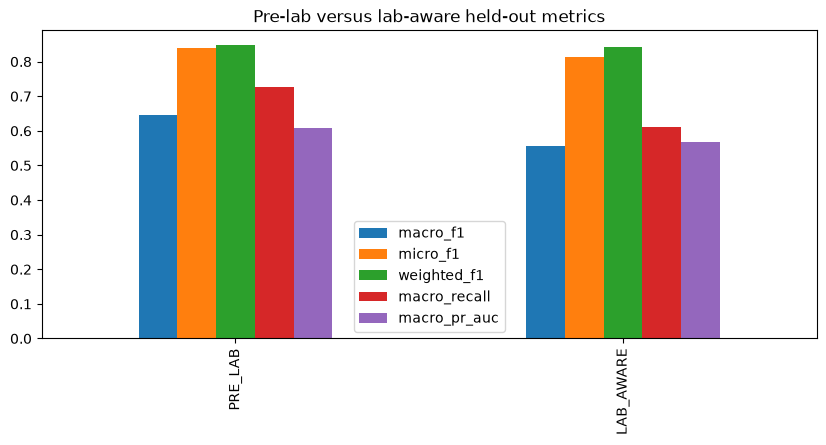

In [10]:
comparison = pd.DataFrame(summary["test_metrics"]).T[
    ["macro_f1", "micro_f1", "weighted_f1", "macro_recall", "macro_pr_auc"]
]
display(comparison.loc[["PRE_LAB", "LAB_AWARE"]])
comparison.loc[["PRE_LAB", "LAB_AWARE"]].plot(kind="bar", figsize=(10, 4), title="Pre-lab versus lab-aware held-out metrics")

> **Key Takeaway**
>
> Laboratory availability changes the model's role. VECTRA-X preserves this distinction instead of mixing confirmation evidence into an early-triage claim.

# 13. Full-Feature Leakage Demonstration

The full-feature track deliberately shows what happens when a target-restatement
variable enters the feature matrix. Unrealistically strong performance is
treated as evidence of leakage awareness, not as the headline model result.

In [11]:
display(comparison.loc[["PRE_LAB", "FULL"]])
dengue = per_label[(per_label["label"] == "dengue") & per_label["track"].isin(["PRE_LAB", "FULL"])]
display(dengue[["track", "precision", "recall", "f1", "roc_auc", "pr_auc"]])

,macro_f1,micro_f1,weighted_f1,macro_recall,macro_pr_auc
PRE_LAB,0.6467,0.8400,0.8476,0.7253,0.6078
FULL,0.7049,0.8927,0.9087,0.7069,0.6818


,track,precision,recall,f1,roc_auc,pr_auc
2,PRE_LAB,0.4762,0.7143,0.5714,0.8016,0.4548
12,FULL,1.0000,0.8571,0.9231,0.9977,0.9911


> **Key Takeaway**
>
> Dengue F1 increases sharply in the full track because a leakage candidate nearly restates the outcome. The result strengthens the methodological defense for the pre-lab model.

# 14. Threshold Optimization

A default threshold of 0.5 does not reflect disease imbalance or asymmetric
clinical cost. VECTRA-X defines three policies:

- **Performance:** maximize per-label F1.
- **Safety:** lower selected severe or rare-label thresholds to improve recall.
- **Operational:** balance recall with confirmatory-test and review capacity.

In [12]:
policies = read_table("threshold_policies.csv")
display(policies)
policy_long = policies.melt(id_vars="label", var_name="policy", value_name="threshold")
px.line(
    policy_long,
    x="label",
    y="threshold",
    color="policy",
    markers=True,
    title="Per-label threshold policies",
    labels={"label": "Disease", "threshold": "Decision threshold", "policy": "Policy"},
).show()

,label,performance,safety,operational
0,malaria,0.05,0.05,0.05
1,other_diseases,0.50,0.50,0.50
2,dengue,0.35,0.20,0.35
3,typhoid,0.50,0.45,0.50
4,yellow_fever,0.25,0.05,0.10


> **Key Takeaway**
>
> The operational policy is recommended for the main demonstration because it connects model behavior to realistic response capacity; the safety policy is available for sensitivity analysis.

# 15. Calibration

Calibration asks whether a predicted probability corresponds to observed
frequency. This matters for triage because a confidence score should support
prioritization and communication, not merely rank patients.

In [13]:
calibration = read_table("calibration_metrics.csv")
display(calibration)
show_figure("calibration_curves.png", "Calibration curves for the primary pre-lab model")

,label,base_rate,brier,ece,mean_pred,variant
0,malaria,0.8701,0.1071,0.0579,0.8461,uncalibrated
1,other_diseases,0.3247,0.0380,0.1337,0.3387,uncalibrated
2,dengue,0.1818,0.1299,0.0922,0.2600,uncalibrated
3,typhoid,0.0909,0.1008,0.1121,0.1588,uncalibrated
4,yellow_fever,0.0390,0.0338,0.0445,0.0796,uncalibrated
5,malaria,0.8701,0.1109,0.0465,0.9167,calibrated
6,other_diseases,0.3247,0.0146,0.0237,0.3224,calibrated
7,dengue,0.1818,0.1219,0.0715,0.1714,calibrated
8,typhoid,0.0909,0.0793,0.0513,0.0835,calibrated
9,yellow_fever,0.0390,0.0363,0.0020,0.0370,calibrated


![Calibration curves for the primary pre-lab model](C:/Users/rapha/Documents/VSCode/Kaggle/FIT/vectra_x_project/outputs/figures/calibration_curves.png)

> **Key Takeaway**
>
> The mean pre-lab Brier score is reported from the verified summary artifact. Calibration evidence is shown alongside discrimination metrics.

# 16. Uncertainty Estimation

Patient uncertainty combines predictive entropy, confidence, top-two margin,
and conformal set size. Low uncertainty suggests a comparatively stable model
output; high uncertainty indicates that manual review or confirmatory testing
should receive greater priority.

In [14]:
uncertainty = read_table("patient_uncertainty_scores.csv")
display(uncertainty["uncertainty_level"].value_counts().rename_axis("level").reset_index(name="patients"))
px.histogram(
    uncertainty,
    x="mean_entropy",
    color="uncertainty_level",
    nbins=25,
    title="Patient uncertainty score distribution",
    labels={"mean_entropy": "Mean predictive entropy", "count": "Patients"},
).show()

,level,patients
0,moderate,138
1,low,118
2,high,44


# 17. Conformal Prediction

Conformal prediction produces a set of plausible diseases rather than forcing
one answer. Coverage describes how often the true label is included; average
set size describes how specific the system can be. In ambiguous cases, a
multi-disease set is safer than an overconfident single diagnosis.

In [15]:
conformal_metrics = read_table("conformal_metrics.csv")
conformal_examples = read_table("conformal_prediction_examples.csv")
display(pd.DataFrame([summary["conformal"]]))
display(conformal_metrics)
display(conformal_examples.head(12))

,avg_set_size,pct_empty_sets,pct_singletons,pct_ambiguous_multi,overall_coverage
0,2.8961,0.0,5.19,94.81,0.9483


,label,prob_threshold,test_positives,covered_positives,empirical_coverage,predicted_inclusions
0,malaria,0.6212,67,66,0.9851,75
1,other_diseases,0.6025,25,24,0.9600,24
2,dengue,0.1610,14,13,0.9286,37
3,typhoid,0.0775,7,4,0.5714,33
4,yellow_fever,0.0130,3,3,1.0000,54


,uuid,prediction_set,set_size,true_labels,interpretation,max_prob
0,eb694f52-51ff-488d-9beb-2923a572a4cf,"{malaria, dengue, typhoid, yellow_fever}",4,{malaria},ambiguous — request confirmatory testing,0.894
1,3f96e3e8-d1ed-4ff4-b945-8088af180529,"{malaria, dengue, typhoid, yellow_fever}",4,"{malaria, dengue}",ambiguous — request confirmatory testing,0.823
2,f41c7b5c-d560-4352-82b2-cebfcdf2a68a,"{malaria, dengue, typhoid, yellow_fever}",4,"{malaria, dengue}",ambiguous — request confirmatory testing,0.874
3,83257713-90ef-47db-acb6-f977a4b8ee1a,"{malaria, dengue, typhoid, yellow_fever}",4,"{dengue, yellow_fever}",ambiguous — request confirmatory testing,0.874
4,76d34d9f-4f0b-4bb3-b610-8f41510b0aab,"{malaria, dengue, typhoid, yellow_fever}",4,{dengue},ambiguous — request confirmatory testing,0.707
5,f5c31a1e-6059-44fb-8d10-feb7891a93ea,"{malaria, other_diseases, typhoid, yellow_fever}",4,"{malaria, other_diseases}",ambiguous — request confirmatory testing,0.881
6,2e80ed76-27fd-467c-b9d8-fa3be6dd72a3,"{malaria, typhoid}",2,{malaria},ambiguous — request confirmatory testing,0.944
7,708eccbd-9604-491a-b41c-6026aba3c908,"{malaria, other_diseases, dengue, typhoid, yel...",5,"{malaria, other_diseases}",ambiguous — request confirmatory testing,0.806
8,8648cafa-454c-45d1-80e2-afdb5f25fd2b,"{malaria, other_diseases, dengue, typhoid, yel...",5,"{other_diseases, dengue}",ambiguous — request confirmatory testing,0.798
9,cc1f97c7-8bef-484a-9fc5-7ea18c162db5,"{malaria, dengue, typhoid, yellow_fever}",4,{malaria},ambiguous — request confirmatory testing,0.934


> **Key Takeaway**
>
> Empirical coverage and average set size are reported from the verified conformal artifact. The broad sets appropriately communicate ambiguity, but rare-label coverage remains limited by sample size.

# 18. Explainability

Global and per-label permutation importance describe which signals affect model
performance. Local explanations illustrate representative patient cases. SHAP
is included when available, with permutation importance retained as the
dependency-light fallback.

> **Warning:** Because features may be anonymized or encrypted, explanations
> are model-based statistical signals, not direct medical causality.

In [16]:
importance_global = read_table("feature_importance_global.csv")
importance_label = read_table("feature_importance_per_label.csv")
display(importance_global.head(20))
if not importance_global.empty:
    px.bar(
        importance_global.head(20).sort_values("importance_mean"),
        x="importance_mean",
        y="feature",
        orientation="h",
        title="Global permutation importance",
        labels={"importance_mean": "Mean importance", "feature": "Feature"},
    ).show()
display(importance_label.groupby("label").head(5))
show_figure("local_explanation_examples.png", "Representative local patient explanations")
show_figure("shap_summary.png", "Optional SHAP summary")

,feature,importance_mean
0,autres_maladies_pr_sent_es_par_le_patien__present,0.093634
1,Température axillaire (médiane IQR) (°C) /Axil...,0.032292
2,Douleur abdominale (stomac pain),0.017098
3,Diabète,0.013948
4,Douleur articulaire (Joint pain),0.012182
5,Vertige (Dizzy),0.010592
6,"Haute température.(temperature, Hyperpyrexia)",0.009480
7,Convulsions multiples (Multiple convulsions),0.007742
8,Convulsions généralisées ou focales (Generalis...,0.007418
9,Céphalée (Headache),0.006510


,label,feature,importance_mean,importance_std
0,dengue,Sensation de frissons ou de froid (Shiver or c...,0.04624,0.02921
1,dengue,Pâleur cutanéo muqueuse ou Anémie (Mucosal ski...,0.04523,0.00757
2,dengue,Douleur articulaire (Joint pain),0.02585,0.05272
3,dengue,center_code,0.01871,0.03276
4,dengue,"Haute température.(temperature, Hyperpyrexia)",0.01307,0.03310
82,malaria,Pâleur cutanéo muqueuse ou Anémie (Mucosal ski...,0.01561,0.01064
83,malaria,Somnolence ou léthargie (Drowsiness or lethargy),0.01423,0.01283
84,malaria,Sensation de frissons ou de froid (Shiver or c...,0.01147,0.00392
85,malaria,Douleur abdominale (stomac pain),0.00646,0.00436
86,malaria,Douleur articulaire (Joint pain),0.00580,0.00636


![Representative local patient explanations](C:/Users/rapha/Documents/VSCode/Kaggle/FIT/vectra_x_project/outputs/figures/local_explanation_examples.png)

![Optional SHAP summary](C:/Users/rapha/Documents/VSCode/Kaggle/FIT/vectra_x_project/outputs/figures/shap_summary.png)

# 19. Fairness and Robustness Audit

Performance is evaluated across available center, gender, and age-group
subgroups. Recall gaps and false-negative behavior are emphasized. A
leave-one-center-out test measures whether the system transfers across
facilities with different workflows or patient distributions.

In [17]:
fairness = read_table("fairness_metrics.csv")
fairness_gaps = read_table("fairness_recall_gaps.csv")
loco = read_table("leave_one_center_out.csv")
display(fairness)
display(fairness_gaps)
display(loco)
if not fairness_gaps.empty:
    px.bar(
        fairness_gaps,
        x="label",
        y="recall_gap",
        color="axis",
        barmode="group",
        title="Subgroup recall gaps",
        labels={"label": "Disease", "recall_gap": "Maximum recall gap", "axis": "Audit axis"},
    ).show()

,axis,level,n,macro_f1,recall_malaria,recall_other_diseases,recall_dengue,recall_typhoid,recall_yellow_fever
0,gender,Homme,46,0.7200,1.0,1.0000,0.6667,0.5000,1.0
1,gender,Femme,30,0.5741,1.0,1.0000,0.8000,0.0000,0.5
2,center,CMA de DO,37,0.7100,1.0,1.0000,0.7500,0.5000,1.0
3,center,CMA de DAFRA,40,0.4341,1.0,0.9474,0.5000,0.0000,0.0
4,age_group,child_6_12,16,0.6867,1.0,1.0000,1.0000,0.0000,0.5
5,age_group,adult_19_50,17,0.5551,1.0,1.0000,1.0000,0.3333,NaN
6,age_group,elderly_>50,13,0.5433,1.0,1.0000,1.0000,NaN,NaN
7,age_group,adolescent_13_18,7,0.7055,1.0,0.6667,0.0000,1.0000,1.0
8,age_group,infant_<=5,23,0.3956,1.0,1.0000,0.0000,0.0000,NaN


,axis,label,max_recall,min_recall,recall_gap,worst_level
0,gender,malaria,1.00,1.0000,0.0000,Homme
1,gender,other_diseases,1.00,1.0000,0.0000,Homme
2,gender,dengue,0.80,0.6667,0.1333,Homme
3,gender,typhoid,0.50,0.0000,0.5000,Femme
4,gender,yellow_fever,1.00,0.5000,0.5000,Femme
5,center,malaria,1.00,1.0000,0.0000,CMA de DO
6,center,other_diseases,1.00,0.9474,0.0526,CMA de DAFRA
7,center,dengue,0.75,0.5000,0.2500,CMA de DAFRA
8,center,typhoid,0.50,0.0000,0.5000,CMA de DAFRA
9,center,yellow_fever,1.00,0.0000,1.0000,CMA de DAFRA


,train_on,test_on,n_test,macro_f1,micro_f1,recall_malaria,recall_other_diseases,recall_dengue,recall_typhoid,recall_yellow_fever
0,others,CMA de DO,147,0.3782,0.7765,0.9779,0.9697,0.0,0.0,0.0
1,others,CMA de DAFRA,153,0.3721,0.8640,1.0000,0.9545,0.0,0.0,0.0


> **Key Takeaway**
>
> Leave-one-center-out macro F1 falls to approximately 0.38. This is a major generalization limitation and a strong argument for prospective, facility-specific validation.

# 20. Co-Infection Detection

A separate binary model estimates whether a patient carries more than one
active diagnosis. This supports confirmatory-test prioritization and resource
planning beyond the individual disease classifiers.

In [18]:
coinfection = read_table("coinfection_model_metrics.csv")
display(coinfection)
px.bar(
    coinfection,
    x="model",
    y=["roc_auc", "pr_auc"],
    barmode="group",
    title="Co-infection model benchmark",
    labels={"value": "Score", "model": "Model", "variable": "Metric"},
).show()

,model,roc_auc,pr_auc
0,extra_trees,0.8628,0.8714
1,logreg,0.8625,0.8746
2,random_forest,0.8525,0.8503
3,hist_gb,0.8447,0.8657
4,xgboost,0.8418,0.8629
5,lightgbm,0.8407,0.8556


> **Key Takeaway**
>
> The best co-infection detector reports strong ROC-AUC and recall, indicating that pre-lab signals contain useful information about multi-disease burden.

# 21. VECTRA-X Triage Engine

The triage score combines label-weighted calibrated risk, severe-disease
probability, uncertainty, and co-infection probability. Transparent rules map
patients to:

- Routine Monitoring
- Clinical Review
- Confirmatory Test Priority
- Urgent Response Priority

The result is an operational recommendation, not a treatment instruction.

In [19]:
patients = read_table("vectra_patient_level_predictions.csv")

def label_count(value):
    text = str(value).strip("{}")
    return 0 if not text or text == "none" else len([x for x in text.split(",") if x.strip()])

case_frames = {
    "high_confidence_single_disease": patients[
        (patients["uncertainty_level"] == "low") &
        (patients["predicted_labels"].map(label_count) == 1)
    ],
    "coinfection_case": patients[patients["predicted_labels"].map(label_count) > 1],
    "high_uncertainty_case": patients[patients["uncertainty_level"] == "high"],
    "urgent_priority_case": patients[patients["triage_category"] == "Urgent Response Priority"],
    "false_negative_risk_case": patients[
        patients.apply(
            lambda row: bool(
                set(str(row.get("true_labels", "")).strip("{}").split(", ")) -
                set(str(row.get("predicted_labels", "")).strip("{}").split(", "))
            ),
            axis=1,
        )
    ],
}
case_cards = pd.concat(
    [frame.head(1).assign(case_type=name) for name, frame in case_frames.items() if not frame.empty],
    ignore_index=True,
)
columns = [
    "case_type", "uuid", "predicted_labels", "true_labels", "conformal_set",
    "coinfection_prob", "uncertainty_level", "triage_score",
    "triage_category", "recommended_action",
]
display(case_cards[[c for c in columns if c in case_cards]])
case_cards.to_csv(FINAL_OUTPUT / "patient_case_cards.csv", index=False)

,case_type,uuid,predicted_labels,true_labels,conformal_set,coinfection_prob,uncertainty_level,triage_score,triage_category,recommended_action
0,high_confidence_single_disease,923232c9-6454-44a7-9e08-c87d77163e57,{malaria},{malaria},"{malaria, typhoid}",0.3057,low,0.1922,Routine Monitoring,"Routine monitoring; document symptoms, no imme..."
1,coinfection_case,df22d899-23a3-4c49-8059-6208c130f57d,"{malaria, dengue}","{malaria, dengue}","{malaria, dengue, typhoid, yellow_fever}",0.8690,moderate,0.4461,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
2,high_uncertainty_case,95c3917b-1714-4210-8861-21f08d80b561,"{malaria, dengue, yellow_fever}","{malaria, dengue}","{dengue, typhoid, yellow_fever}",0.6070,high,0.3885,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
3,urgent_priority_case,df22d899-23a3-4c49-8059-6208c130f57d,"{malaria, dengue}","{malaria, dengue}","{malaria, dengue, typhoid, yellow_fever}",0.8690,moderate,0.4461,Urgent Response Priority,Flag for urgent clinical evaluation / referral.
4,false_negative_risk_case,104f6bc8-f39a-482b-b680-7ac1f8cccc86,"{malaria, dengue}","{malaria, typhoid}","{malaria, dengue, typhoid, yellow_fever}",0.8051,moderate,0.4798,Urgent Response Priority,Flag for urgent clinical evaluation / referral.


> **Key Takeaway**
>
> The triage layer converts probabilistic outputs into transparent response categories while preserving uncertainty and the need for clinical review.

# 22. Resource Prioritization Simulation

Resource simulation estimates urgent patients, confirmatory-test demand,
monitoring need, dominant predicted diseases, and operational burden under
different threshold policies. Assumptions are intentionally transparent and
are adjustable in the Streamlit dashboard.

In [20]:
resource = read_table("resource_simulation.csv")
policy_resource = read_table("threshold_policy_resource_tradeoff.csv")
display(resource)
display(policy_resource)
px.bar(
    policy_resource,
    x="policy",
    y="total_flags",
    title="Threshold policy and operational burden",
    labels={"policy": "Threshold policy", "total_flags": "Total disease flags"},
).show()
resource.to_csv(FINAL_OUTPUT / "resource_simulation.csv", index=False)

,metric,count,pct
0,total_patients,300,100.00
1,predicted_malaria,300,100.00
2,predicted_other_diseases,94,31.33
3,predicted_dengue,102,34.00
4,predicted_typhoid,43,14.33
5,predicted_yellow_fever,44,14.67
6,tier_Routine_Monitoring,66,22.00
7,tier_Clinical_Review,87,29.00
8,tier_Confirmatory_Test_Priority,88,29.33
9,tier_Urgent_Response_Priority,59,19.67


,policy,flagged_malaria,flagged_other_diseases,flagged_dengue,flagged_typhoid,flagged_yellow_fever,total_flags,avg_flags_per_patient
0,performance,300,94,102,43,44,583,1.943
1,safety,300,94,152,48,161,755,2.517
2,operational,300,94,102,43,110,649,2.163


> **Key Takeaway**
>
> Threshold selection changes workload. Presenting this trade-off makes VECTRA-X a response-planning system rather than an isolated predictive model.

# 23. Dashboard Prototype Overview

The Streamlit dashboard is a functional prototype rather than a static report.
Judges can:

- Switch between pre-lab, lab-aware, and research-only model contexts.
- Change threshold policy.
- Select representative or individual patients.
- Upload original-schema CSV files for saved-model inference.
- Filter the population and download triage outputs.
- Adjust rapid-test, bed, monitoring, and staff capacity.
- Inspect model performance, calibration, uncertainty, explainability, and fairness.

Run from the project root:

```powershell
streamlit run app/streamlit_app.py
```

# 24. Final Discussion

VECTRA-X differs from generic disease classification in five ways:

1. It preserves multi-label and co-infection structure.
2. It explicitly separates pre-lab triage from lab-aware confirmation.
3. It treats leakage detection as a methodological contribution.
4. It communicates calibrated confidence, uncertainty, and conformal sets.
5. It connects predictions to triage and resource decisions.

## Why VECTRA-X Can Win

Many competitor solutions are likely to present a single XGBoost classifier,
accuracy, a small set of EDA charts, and a static dashboard. VECTRA-X offers a
stronger scientific defense and a more complete humanitarian workflow. It
shows not only which model performs best, but which information is available
at each clinical stage, when the model is uncertain, where it may fail across
facilities, and how its outputs change response capacity.

# 25. Limitations and Ethics

- VECTRA-X is not a replacement for medical diagnosis or professional judgment.
- The dataset contains only 300 patients and very few positives for rare labels.
- Performance estimates for yellow fever and typhoid have wide uncertainty.
- Center transfer performance indicates substantial domain shift.
- Some features are anonymized, bilingual, or operationally ambiguous.
- Full-feature performance is affected by target-restatement leakage.
- Conformal coverage for rare labels is approximate under limited calibration data.
- Prospective clinical validation, governance, consent, and monitoring are required.

# 26. Conclusion and Recommendations

**Final model recommendation:** present the pre-lab Extra Trees model as the
primary operational model. Use the lab-aware model only after tests are
available. Retain the full-feature model exclusively as a leakage demonstration.

**Final system recommendation:** present VECTRA-X as a staged decision-support
workflow combining multi-label prediction, uncertainty-aware review,
co-infection detection, triage prioritization, and resource simulation.

Future work should collect more rare-label cases, add prospective multi-center
validation, monitor calibration over time, integrate real-time and
geospatial/climate data when timestamps and locations become available, and
co-design deployment with health workers.

# 27. Appendix

## Configuration

- Random state: 42
- Multi-label stratified train/test split
- Five-fold out-of-fold model selection
- Project-relative paths
- Saved model bundles under `outputs/models/`

## Reproducibility Notes

Fast verified execution:

```powershell
jupyter nbconvert --execute --to notebook --inplace notebooks/VECTRA_X_Final_Competition_Notebook.ipynb
```

Full deterministic recomputation:

```powershell
$env:VECTRA_X_RECOMPUTE="1"
jupyter nbconvert --execute --to notebook --inplace notebooks/VECTRA_X_Final_Competition_Notebook.ipynb
```

## Generated Outputs

Notebook-specific exports are written to `outputs/final_notebook/`.

## References Placeholder

Final submission references should include WHO and CDC vector-borne disease
guidance; multi-label classification; iterative stratification; probability
calibration; conformal prediction; SHAP; XGBoost; LightGBM; and healthcare
algorithm fairness literature.

In [21]:
final_summary = {
    "project": "VECTRA-X",
    "execution_mode": "full_recomputation" if RECOMPUTE_MODELS else "artifact_backed",
    "random_state": RANDOM_STATE,
    "primary_model": summary["best_model_per_track"]["PRE_LAB"],
    "pre_lab_metrics": summary["test_metrics"]["PRE_LAB"],
    "conformal": summary["conformal"],
    "coinfection": summary["coinfection"],
}
(FINAL_OUTPUT / "execution_summary.json").write_text(
    json.dumps(final_summary, indent=2), encoding="utf-8"
)
pd.DataFrame(summary["test_metrics"]).T.to_csv(
    FINAL_OUTPUT / "held_out_track_metrics.csv"
)
print("Notebook execution completed.")
print("Outputs:", sorted(path.name for path in FINAL_OUTPUT.iterdir()))

Notebook execution completed.
Outputs: ['.gitkeep', 'execution_summary.json', 'held_out_track_metrics.csv', 'leakage_candidates.csv', 'model_leaderboard.csv', 'patient_case_cards.csv', 'resource_simulation.csv']
